# Part 1 — Step 3: Dataset Loading & Preparation
**Techniques applied:** Load CSV, inspect, drop duplicates, handle missing values, detect & remove outliers, encode categoricals, scale features.

Run this notebook **after** `agriculture_dataset_generator.ipynb`.

In [2]:
# ── Cell 1 : Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded.")

Libraries loaded.


In [3]:
# ── Cell 2 : Load Dataset 1 ───────────────────────────────────────────────────
df = pd.read_csv('datasets/dataset1_agriculture_raw.csv')

print(f"Shape loaded  : {df.shape}")
print(f"Columns       : {list(df.columns)}")
print()
df.head()

Shape loaded  : (2040, 15)
Columns       : ['soil_type', 'crop_type', 'growth_stage', 'temperature_C', 'humidity_pct', 'rainfall_mm', 'soil_moisture_pct', 'soil_pH', 'nitrogen_mgkg', 'phosphorus_mgkg', 'potassium_mgkg', 'field_area_ha', 'water_allocation_L_ha', 'fertilizer_N_kg_ha', 'fertilizer_P_kg_ha']



,soil_type,crop_type,growth_stage,temperature_C,humidity_pct,rainfall_mm,soil_moisture_pct,soil_pH,nitrogen_mgkg,phosphorus_mgkg,potassium_mgkg,field_area_ha,water_allocation_L_ha,fertilizer_N_kg_ha,fertilizer_P_kg_ha
0,Loam,Potato,Fruiting,24.2,34.7,69.3,22.1,6.0,147.6,65.0,284.7,40.0,137.6,36.84,24.27
1,Silty,Tomato,Fruiting,29.7,25.1,7.9,24.1,7.4,117.4,77.6,207.2,47.7,415.6,41.07,8.93
2,Sandy,Sunflower,Fruiting,37.2,69.2,23.0,41.3,6.1,99.0,79.0,361.7,3.5,202.9,41.48,12.05
3,Loam,Wheat,Vegetative,16.3,48.2,48.9,20.3,7.8,178.8,78.2,267.9,19.9,121.9,11.49,11.81
4,Loam,Sunflower,Vegetative,14.0,84.4,112.4,28.3,5.5,NaN,26.5,396.6,24.6,30.0,14.00,31.15


In [4]:
# ── Cell 3 : Initial inspection ───────────────────────────────────────────────
print("=== Data Types ===")
print(df.dtypes)
print()
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing count'] > 0])
print()
print("=== Duplicate Rows ===")
print(f"Duplicates: {df.duplicated().sum()}")

=== Data Types ===
soil_type                    str
crop_type                    str
growth_stage                 str
temperature_C            float64
humidity_pct             float64
rainfall_mm              float64
soil_moisture_pct        float64
soil_pH                  float64
nitrogen_mgkg            float64
phosphorus_mgkg          float64
potassium_mgkg           float64
field_area_ha            float64
water_allocation_L_ha    float64
fertilizer_N_kg_ha       float64
fertilizer_P_kg_ha       float64
dtype: object

=== Missing Values ===
                   Missing count  Missing %
humidity_pct                  97       4.75
rainfall_mm                   94       4.61
soil_moisture_pct             96       4.71
nitrogen_mgkg                101       4.95
phosphorus_mgkg              129       6.32

=== Duplicate Rows ===
Duplicates: 40


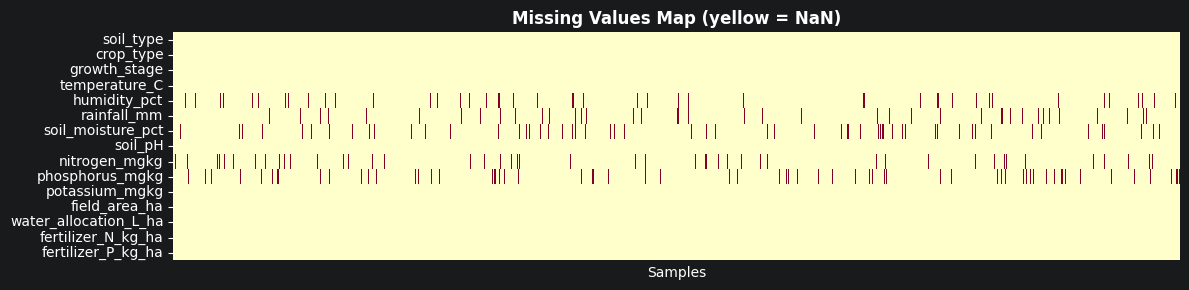

In [5]:
# ── Cell 4 : Visualise missing values (heatmap) ───────────────────────────────
fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(
    df.isnull().T,
    cmap='YlOrRd', cbar=False, ax=ax,
    xticklabels=False
)
ax.set_title('Missing Values Map (yellow = NaN)', fontsize=12, fontweight='bold')
ax.set_xlabel('Samples')
plt.tight_layout()
plt.savefig('cleaning_missing_map.png', dpi=120)
plt.show()

In [6]:
# ── Cell 5 : Step 1 — Drop duplicate rows ─────────────────────────────────────
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
n_after = len(df)

print(f"Rows before : {n_before}")
print(f"Rows after  : {n_after}")
print(f"Dropped     : {n_before - n_after} duplicate rows")

Rows before : 2040
Rows after  : 2000
Dropped     : 40 duplicate rows


In [7]:
# ── Cell 6 : Step 2 — Handle missing values (median imputation) ───────────────
#
# Median is preferred over mean for skewed distributions and
# is robust to the outliers we injected earlier.
# We use sklearn's SimpleImputer to keep the pipeline reproducible.
# ─────────────────────────────────────────────────────────────────────────────

NUMERIC_COLS = df.select_dtypes(include='number').columns.tolist()

imputer = SimpleImputer(strategy='median')
df[NUMERIC_COLS] = imputer.fit_transform(df[NUMERIC_COLS])

print(f"Missing values remaining: {df.isnull().sum().sum()}")
print("Median imputation applied to all numeric columns.")

Missing values remaining: 0
Median imputation applied to all numeric columns.


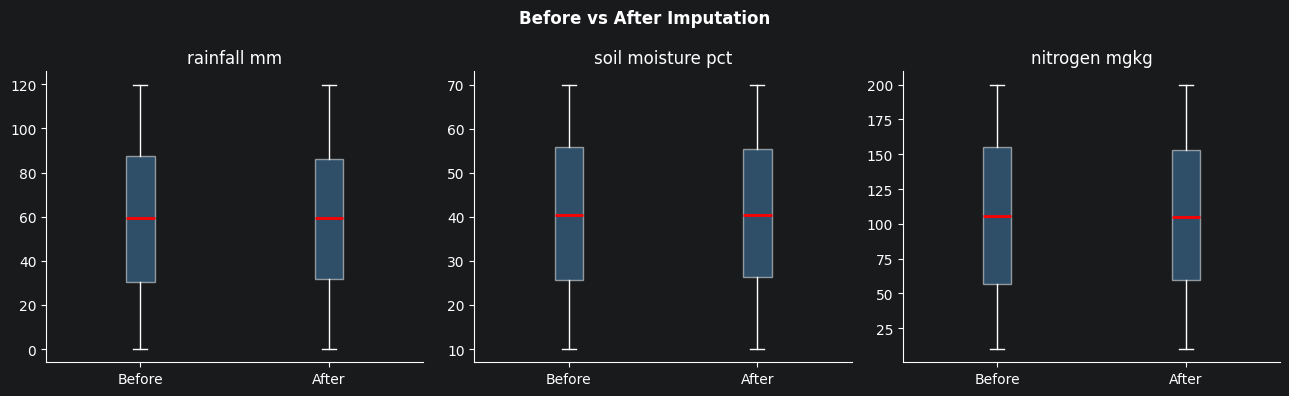

In [8]:
# ── Cell 7 : Verify imputation with before/after boxplots ────────────────────
# Reload raw for comparison
df_raw = pd.read_csv('datasets/dataset1_agriculture_raw.csv')

cols_check = ['rainfall_mm', 'soil_moisture_pct', 'nitrogen_mgkg']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Before vs After Imputation', fontsize=12, fontweight='bold')

for ax, col in zip(axes, cols_check):
    data_before = df_raw[col].dropna()
    data_after  = df[col]
    ax.boxplot([data_before, data_after], labels=['Before', 'After'],
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.5),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col.replace('_', ' '))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('cleaning_imputation_check.png', dpi=120)
plt.show()

In [9]:
# ── Cell 8 : Step 3 — Outlier detection with IQR method ──────────────────────
#
# IQR rule: values outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR] are outliers.
# Applied only on numeric feature columns (not on targets).
# ─────────────────────────────────────────────────────────────────────────────

FEATURE_COLS = [
    'temperature_C', 'humidity_pct', 'rainfall_mm',
    'soil_moisture_pct', 'soil_pH', 'nitrogen_mgkg',
    'phosphorus_mgkg', 'potassium_mgkg', 'field_area_ha'
]

def detect_outliers_iqr(df, cols, factor=1.5):
    outlier_mask = pd.Series([False] * len(df), index=df.index)
    details = {}
    for col in cols:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        mask  = (df[col] < lower) | (df[col] > upper)
        details[col] = {'lower': round(lower,2), 'upper': round(upper,2), 'count': mask.sum()}
        outlier_mask |= mask
    return outlier_mask, details

outlier_mask, outlier_details = detect_outliers_iqr(df, FEATURE_COLS)

print("Outlier counts per column (IQR × 1.5):")
for col, info in outlier_details.items():
    if info['count'] > 0:
        print(f"  {col:<25}  bounds=[{info['lower']}, {info['upper']}]  outliers={info['count']}")

print(f"\nTotal rows flagged as outliers : {outlier_mask.sum()}")

Outlier counts per column (IQR × 1.5):
  temperature_C              bounds=[-6.65, 58.55]  outliers=11

Total rows flagged as outliers : 11


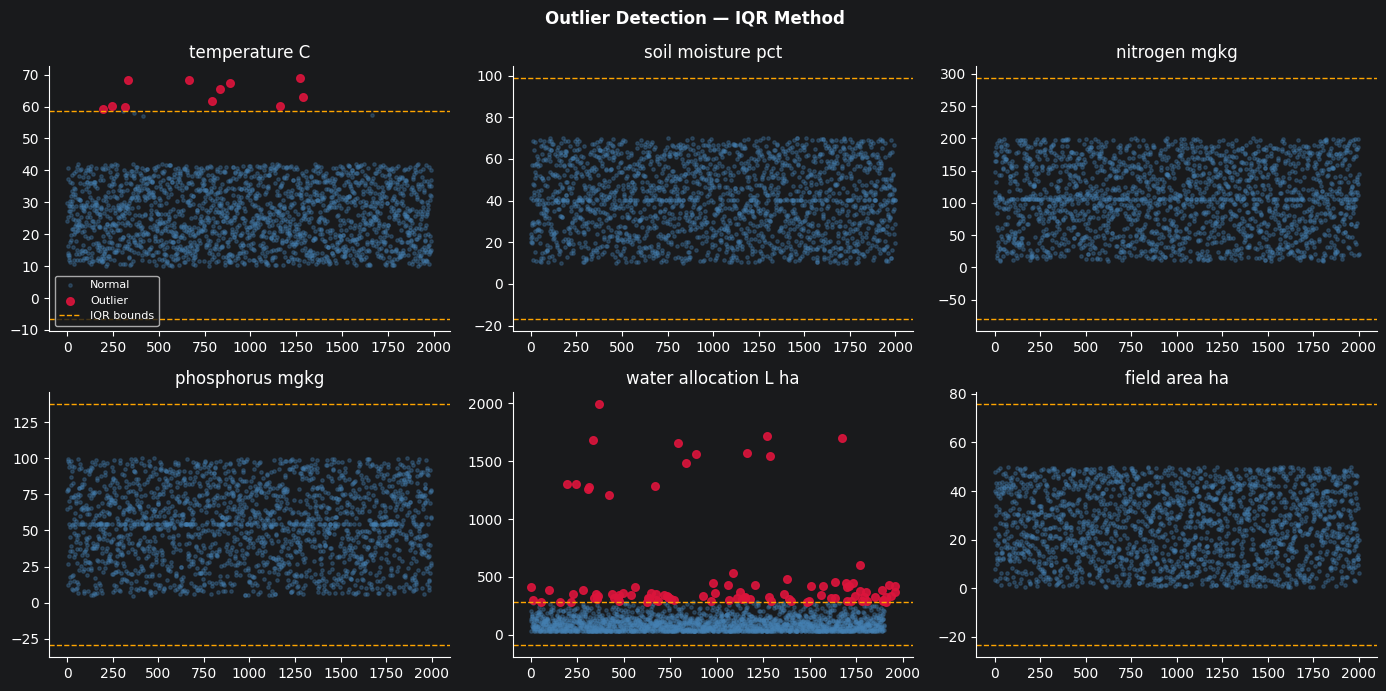

In [10]:
# ── Cell 9 : Visualise outliers with boxplots ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle('Outlier Detection — IQR Method', fontsize=12, fontweight='bold')

highlight_cols = ['temperature_C', 'soil_moisture_pct', 'nitrogen_mgkg',
                  'phosphorus_mgkg', 'water_allocation_L_ha', 'field_area_ha']

for ax, col in zip(axes.flat, highlight_cols):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    inliers  = df[(df[col] >= lower) & (df[col] <= upper)][col]

    ax.scatter(range(len(inliers)),  inliers.values,  alpha=0.3, s=6,  color='steelblue', label='Normal')
    ax.scatter(outliers.index,       outliers.values, alpha=0.9, s=30, color='crimson',   label='Outlier')
    ax.axhline(lower, color='orange', linestyle='--', linewidth=1, label='IQR bounds')
    ax.axhline(upper, color='orange', linestyle='--', linewidth=1)
    ax.set_title(col.replace('_', ' '))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if col == 'temperature_C':
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('cleaning_outliers.png', dpi=120)
plt.show()

In [11]:
# ── Cell 10 : Step 3b — Remove outlier rows ───────────────────────────────────
n_before = len(df)
df_clean = df[~outlier_mask].reset_index(drop=True)
n_after  = len(df_clean)

print(f"Rows before outlier removal : {n_before}")
print(f"Rows after  outlier removal : {n_after}")
print(f"Removed                     : {n_before - n_after} rows")
print(f"Retention rate              : {n_after/n_before*100:.1f}%")

Rows before outlier removal : 2000
Rows after  outlier removal : 1989
Removed                     : 11 rows
Retention rate              : 99.5%


In [12]:
# ── Cell 11 : Step 4 — Encode categorical features ────────────────────────────
#
# Two strategies:
#   A) Label Encoding  → ordinal-like categories (growth stage has a natural order)
#   B) One-Hot Encoding → nominal categories (soil type, crop type)
# We keep both versions for flexibility with different ML algorithms.
# ─────────────────────────────────────────────────────────────────────────────

df_encoded = df_clean.copy()

# ── A) Label Encoding: growth_stage (ordinal order makes agronomic sense) ──
stage_order = ['Seedling', 'Vegetative', 'Flowering', 'Fruiting', 'Harvest']
df_encoded['growth_stage_enc'] = df_encoded['growth_stage'].map(
    {s: i for i, s in enumerate(stage_order)}
)

# ── B) One-Hot Encoding: soil_type and crop_type (nominal) ─────────────────
df_encoded = pd.get_dummies(
    df_encoded,
    columns=['soil_type', 'crop_type'],
    drop_first=True          # avoid multicollinearity
)

# Drop the original growth_stage text column now that we have the numeric version
df_encoded.drop(columns=['growth_stage'], inplace=True)

print(f"Columns after encoding : {df_encoded.shape[1]}")
print("New encoded columns:")
new_cols = [c for c in df_encoded.columns if '_' in c and c not in df_clean.columns]
print(new_cols)

Columns after encoding : 20
New encoded columns:
['growth_stage_enc', 'soil_type_Loam', 'soil_type_Sandy', 'soil_type_Silty', 'crop_type_Potato', 'crop_type_Sunflower', 'crop_type_Tomato', 'crop_type_Wheat']


In [13]:
# ── Cell 12 : Step 5 — Feature scaling ───────────────────────────────────────
#
# Two scalers applied:
#   • StandardScaler  (Z-score) → for algorithms sensitive to variance (PCA, SVM, Neural Nets)
#   • MinMaxScaler    (0-1)     → for algorithms needing bounded ranges (KNN, some DL)
# Target columns are NOT scaled (we scale them separately if needed during training).
# ─────────────────────────────────────────────────────────────────────────────

TARGET_COLS  = ['water_allocation_L_ha', 'fertilizer_N_kg_ha', 'fertilizer_P_kg_ha']
FEATURE_COLS_ENC = [c for c in df_encoded.columns if c not in TARGET_COLS]

X = df_encoded[FEATURE_COLS_ENC].copy()
y = df_encoded[TARGET_COLS].copy()

# ── StandardScaler ──────────────────────────────────────────────────────────
std_scaler = StandardScaler()
X_std = pd.DataFrame(
    std_scaler.fit_transform(X),
    columns=FEATURE_COLS_ENC
)

# ── MinMaxScaler ─────────────────────────────────────────────────────────────
mm_scaler = MinMaxScaler()
X_mm = pd.DataFrame(
    mm_scaler.fit_transform(X),
    columns=FEATURE_COLS_ENC
)

print("StandardScaler — sample statistics after scaling:")
print(X_std[['temperature_C','humidity_pct','rainfall_mm']].describe().loc[['mean','std']].round(4))
print()
print("MinMaxScaler — sample min/max after scaling:")
print(X_mm[['temperature_C','humidity_pct','rainfall_mm']].describe().loc[['min','max']].round(4))

StandardScaler — sample statistics after scaling:
      temperature_C  humidity_pct  rainfall_mm
mean         0.0000        0.0000      -0.0000
std          1.0003        1.0003       1.0003

MinMaxScaler — sample min/max after scaling:
     temperature_C  humidity_pct  rainfall_mm
min            0.0           0.0          0.0
max            1.0           1.0          1.0


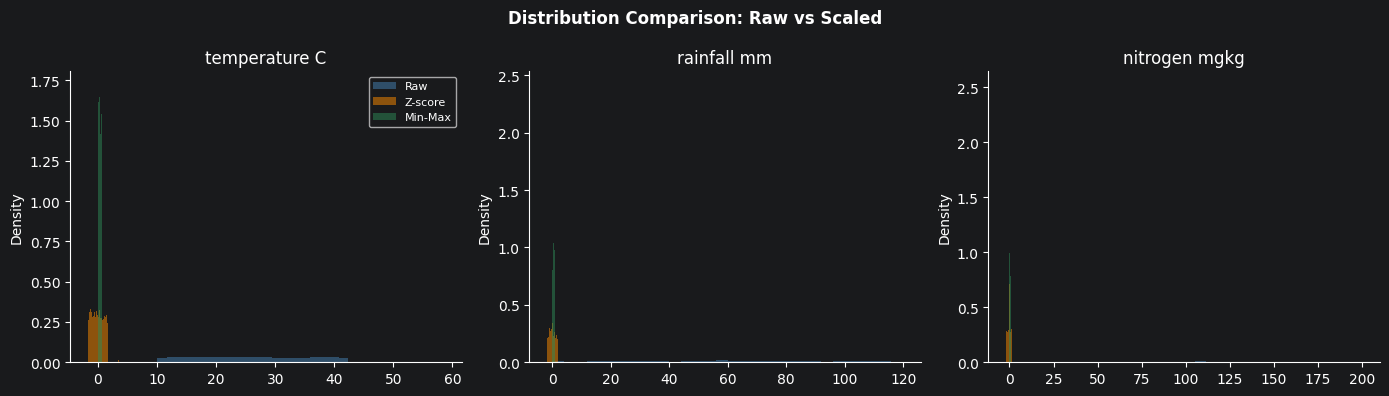

In [14]:
# ── Cell 13 : Visualise effect of scaling ─────────────────────────────────────
cols_to_show = ['temperature_C', 'rainfall_mm', 'nitrogen_mgkg']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Distribution Comparison: Raw vs Scaled', fontsize=12, fontweight='bold')

for ax, col in zip(axes, cols_to_show):
    ax.hist(df_clean[col],  bins=30, alpha=0.5, color='steelblue', label='Raw',      density=True)
    ax.hist(X_std[col],     bins=30, alpha=0.5, color='darkorange',label='Z-score',  density=True)
    ax.hist(X_mm[col],      bins=30, alpha=0.5, color='seagreen',  label='Min-Max',  density=True)
    ax.set_title(col.replace('_', ' '))
    ax.set_ylabel('Density')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if col == 'temperature_C':
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('cleaning_scaling.png', dpi=120)
plt.show()

In [15]:
# ── Cell 14 : Final data quality report ───────────────────────────────────────

print("========================================")
print("   DATASET PREPARATION SUMMARY REPORT   ")
print("========================================")
print(f"  Raw shape           : {pd.read_csv('datasets/dataset1_agriculture_raw.csv').shape}")
print(f"  After dedup         : 2000 rows")
print(f"  After imputation    : 2000 rows  (0 NaN remaining)")
print(f"  After outlier drop  : {len(df_clean)} rows")
print(f"  Features (encoded)  : {len(FEATURE_COLS_ENC)} columns")
print(f"  Targets             : {len(TARGET_COLS)} columns")
print(f"  Scaler A (Z-score)  : X_std — shape {X_std.shape}")
print(f"  Scaler B (Min-Max)  : X_mm  — shape {X_mm.shape}")
print("========================================")
print()
print("Target variable stats (cleaned):")
print(y.describe().round(2))

   DATASET PREPARATION SUMMARY REPORT   
  Raw shape           : (2040, 15)
  After dedup         : 2000 rows
  After imputation    : 2000 rows  (0 NaN remaining)
  After outlier drop  : 1989 rows
  Features (encoded)  : 17 columns
  Targets             : 3 columns
  Scaler A (Z-score)  : X_std — shape (1989, 17)
  Scaler B (Min-Max)  : X_mm  — shape (1989, 17)

Target variable stats (cleaned):
       water_allocation_L_ha  fertilizer_N_kg_ha  fertilizer_P_kg_ha
count                1989.00             1989.00             1989.00
mean                  112.13               54.00               27.32
std                   102.60               33.98               17.31
min                    30.00                0.00                0.00
25%                    50.10               25.53               13.16
50%                    89.20               51.81               25.82
75%                   143.00               77.63               39.31
max                  1990.50              151.42  

In [16]:
# ── Cell 15 : Save clean datasets ─────────────────────────────────────────────
import os
os.makedirs('datasets', exist_ok=True)

# Clean raw (before scaling, after dedup + imputation + outlier removal)
df_clean.to_csv('datasets/dataset1_clean.csv', index=False)

# Encoded + StandardScaled features with targets
df_std = pd.concat([X_std, y.reset_index(drop=True)], axis=1)
df_std.to_csv('datasets/dataset1_clean_std.csv', index=False)

# Encoded + MinMax-scaled features with targets
df_mm = pd.concat([X_mm, y.reset_index(drop=True)], axis=1)
df_mm.to_csv('datasets/dataset1_clean_mm.csv', index=False)

print("Saved:")
print("  datasets/dataset1_clean.csv         (unscaled, encoded)")
print("  datasets/dataset1_clean_std.csv     (Z-score scaled)")
print("  datasets/dataset1_clean_mm.csv      (Min-Max scaled)")

Saved:
  datasets/dataset1_clean.csv         (unscaled, encoded)
  datasets/dataset1_clean_std.csv     (Z-score scaled)
  datasets/dataset1_clean_mm.csv      (Min-Max scaled)


---
## Preparation checklist

| Step | Technique | Tool | Status |
|---|---|---|---|
| Inspect | `.info()`, `.isnull()` | pandas | Done |
| Drop duplicates | `drop_duplicates()` | pandas | Done |
| Handle missing values | Median imputation | sklearn `SimpleImputer` | Done |
| Outlier removal | IQR × 1.5 | numpy / pandas | Done |
| Categorical encoding | Label + One-Hot | pandas `get_dummies` | Done |
| Feature scaling | Z-score + Min-Max | sklearn `StandardScaler / MinMaxScaler` | Done |

**Next step → Feature Engineering (PCA / LDA)**